# Task 3: Learning to Rank
### Датасеты: LETOR (MSLR-WEB10K) / Internet Mathematics 2009 / WikIR (en1k)

**Цель:** сравнить методы Learning-to-Rank (CatBoost YetiRank, QuerySoftMax, PairLogit; LightGBM LambdaRank) на трёх коллекциях и измерить прирост относительно BM25 baseline.  
**Метрика:** NDCG@10 (основная), NDCG@1, NDCG@5.


## 0. Setup

In [ ]:
!pip install catboost lightgbm rank_bm25 scikit-learn pandas numpy scipy matplotlib seaborn tqdm nltk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, re, math, os
from collections import Counter
import catboost as cb
import lightgbm as lgb

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print(f"CatBoost  {cb.__version__}")
print(f"LightGBM  {lgb.__version__}")


CatBoost  1.2.10
LightGBM  4.6.0


## 0.1 Вспомогательные функции

In [3]:
# ── NDCG ─────────────────────────────────────────────────────────────────
def dcg_at_k(rels, k):
    rels = np.asarray(rels[:k], dtype=float)
    if len(rels) == 0: return 0.0
    return float(np.sum((2**rels - 1) / np.log2(np.arange(2, len(rels)+2))))

def ndcg_at_k(rels, k):
    idcg = dcg_at_k(sorted(rels, reverse=True), k)
    return dcg_at_k(rels, k) / idcg if idcg > 0 else 0.0

def evaluate_ranking(y_or_df, score_or_col, query_ids=None,
                     ks=(1, 5, 10), label_col='label'):
    """
    Считает NDCG@k усреднённо по запросам.
    Два режима вызова:
      DataFrame: evaluate_ranking(df, 'score_col')
      Arrays:    evaluate_ranking(y_true, y_score, qids)
    """
    if isinstance(y_or_df, pd.DataFrame):
        df = y_or_df; score_col = score_or_col
        results = {k: [] for k in ks}
        for _, grp in df.groupby('qid'):
            rels = grp.sort_values(score_col, ascending=False)[label_col].tolist()
            for k in ks: results[k].append(ndcg_at_k(rels, k))
    else:
        y_true = np.asarray(y_or_df); y_score = np.asarray(score_or_col)
        qids   = np.asarray(query_ids)
        results = {k: [] for k in ks}
        for qid in np.unique(qids):
            mask  = qids == qid
            order = np.argsort(y_score[mask])[::-1]
            for k in ks: results[k].append(ndcg_at_k(y_true[mask][order].tolist(), k))
    return {f'NDCG@{k}': float(np.mean(v)) for k, v in results.items()}

# ── CatBoost helpers ──────────────────────────────────────────────────────
def sort_by_qid(X, y, g):
    """Сортировка по query id."""
    idx = np.argsort(g, kind='stable')
    return X[idx], y[idx], g[idx], idx

def group_sizes(qids):
    """Размеры групп для LightGBM."""
    sizes, cur, cnt = [], None, 0
    for q in qids:
        if q != cur:
            if cnt: sizes.append(cnt)
            cur, cnt = q, 1
        else: cnt += 1
    if cnt: sizes.append(cnt)
    return sizes

def print_results_table(results_dict, title='Results'):
    df = pd.DataFrame(results_dict).T
    df.index.name = 'Method'
    print(f'\n=== {title} ===')
    print(df.round(4).to_string())
    return df


---
## 1. CatBoost на данных MS LETOR (MSLR-WEB10K)

**Данные:** 10 000 запросов, 136 признаков, метки релевантности 0–4.  
Загружаем встроенный датасет CatBoost (`msrank_10k` — случайная выборка 10k из полного MSLR-WEB10K).


### 1.1 Загрузка данных

In [4]:
from catboost.datasets import msrank_10k

df_tr, df_te = msrank_10k()

# Колонка 0 = relevance label (0–4), 1 = query id, 2..137 = 136 признаков
X_train       = df_tr.drop([0, 1], axis=1).values
y_train       = df_tr[0].values.astype(int)
queries_train = df_tr[1].values.astype(int)

X_test        = df_te.drop([0, 1], axis=1).values
y_test        = df_te[0].values.astype(int)
queries_test  = df_te[1].values.astype(int)

print(f"Train: {X_train.shape[0]:,} пар | {np.unique(queries_train).shape[0]:,} запросов | {X_train.shape[1]} признаков")
print(f"Test : {X_test.shape[0]:,} пар  | {np.unique(queries_test).shape[0]:,} запросов")
print("\nРаспределение меток (train):")
for lbl, cnt in sorted(zip(*np.unique(y_train, return_counts=True))):
    print(f"  {lbl}: {cnt:6,} ({cnt/len(y_train)*100:5.1f}%)  {'█' * int(cnt/len(y_train)*50)}")


Train: 10,000 пар | 87 запросов | 136 признаков
Test : 10,000 пар  | 88 запросов

Распределение меток (train):
  0:  5,481 ( 54.8%)  ███████████████████████████
  1:  3,000 ( 30.0%)  ███████████████
  2:  1,326 ( 13.3%)  ██████
  3:    142 (  1.4%)  
  4:     51 (  0.5%)  


### 1.2 EDA

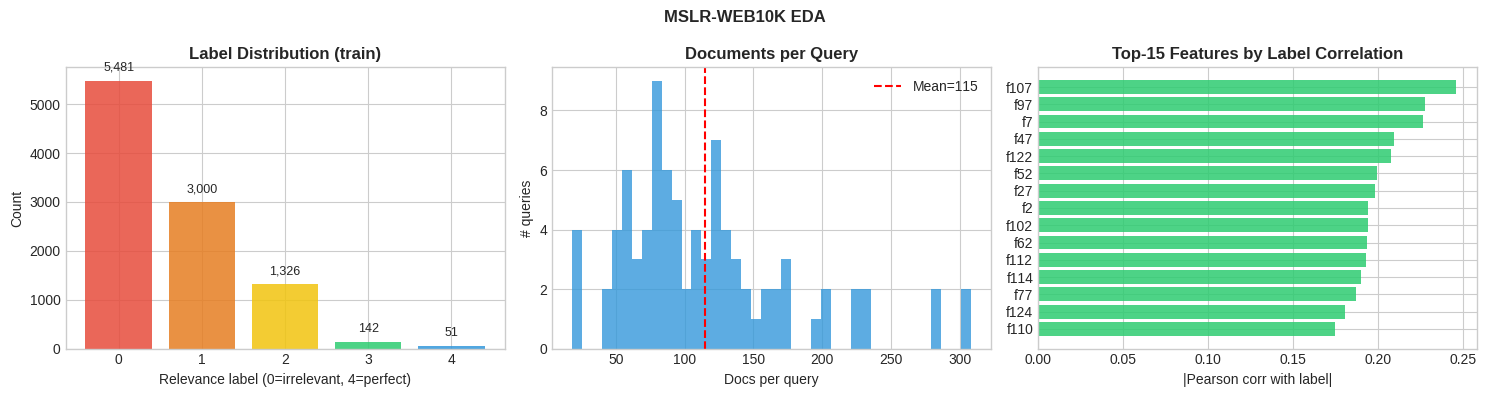

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
labels, counts = np.unique(y_train, return_counts=True)
ax.bar(labels, counts, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'], alpha=0.85)
ax.set_xlabel('Relevance label (0=irrelevant, 4=perfect)')
ax.set_ylabel('Count'); ax.set_title('Label Distribution (train)', fontweight='bold')
for l, c in zip(labels, counts):
    ax.text(l, c + 200, f'{c:,}', ha='center', fontsize=9)

ax = axes[1]
dpq = pd.Series(queries_train).value_counts().values
ax.hist(dpq, bins=40, color='#3498db', alpha=0.8)
ax.axvline(np.mean(dpq), color='red', linestyle='--', label=f'Mean={np.mean(dpq):.0f}')
ax.set_xlabel('Docs per query'); ax.set_ylabel('# queries')
ax.set_title('Documents per Query', fontweight='bold'); ax.legend()

ax = axes[2]
df_feat = pd.DataFrame(X_train, columns=[f'f{i}' for i in range(X_train.shape[1])])
df_feat['label'] = y_train
corrs = df_feat.corr()['label'].drop('label').abs().sort_values(ascending=False).head(15)
ax.barh(corrs.index, corrs.values, color='#2ecc71', alpha=0.85)
ax.set_xlabel('|Pearson corr with label|')
ax.set_title('Top-15 Features by Label Correlation', fontweight='bold'); ax.invert_yaxis()

plt.suptitle('MSLR-WEB10K EDA', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


### 1.3 Подготовка CatBoost Pools

In [6]:
X_tr_s, y_tr_s, q_tr_s, _      = sort_by_qid(X_train, y_train, queries_train)
X_te_s, y_te_s, q_te_s, idx_te = sort_by_qid(X_test,  y_test,  queries_test)

pool_train = cb.Pool(X_tr_s, label=y_tr_s, group_id=q_tr_s)
pool_test  = cb.Pool(X_te_s, label=y_te_s, group_id=q_te_s)
print(f"Train pool: {pool_train.num_row():,} строк, {pool_train.num_col()} признаков")
print(f"Test pool : {pool_test.num_row():,} строк")


Train pool: 10,000 строк, 136 признаков
Test pool : 10,000 строк


### 1.4 Модели

In [7]:
results = {}

# YetiRank
model_yr = cb.CatBoost({'loss_function':'YetiRank','iterations':500,'learning_rate':0.05,
                        'depth':6,'l2_leaf_reg':3,'random_seed':42,'verbose':100,
                        'eval_metric':'NDCG:top=10'})
model_yr.fit(pool_train, eval_set=pool_test)
scores_yr = model_yr.predict(X_te_s)[np.argsort(idx_te)]
results['YetiRank'] = evaluate_ranking(y_test, scores_yr, queries_test)
print("YetiRank:", results['YetiRank'])


0:	test: 0.1422366	best: 0.1422366 (0)	total: 188ms	remaining: 1m 33s
100:	test: 0.4593494	best: 0.4602098 (97)	total: 20.7s	remaining: 1m 21s
200:	test: 0.4792325	best: 0.4792325 (200)	total: 29s	remaining: 43.2s
300:	test: 0.4872544	best: 0.4892838 (289)	total: 35.2s	remaining: 23.3s
400:	test: 0.4973443	best: 0.4975519 (399)	total: 41.7s	remaining: 10.3s
499:	test: 0.4966734	best: 0.5002186 (458)	total: 47.7s	remaining: 0us

bestTest = 0.5002185595
bestIteration = 458

Shrink model to first 459 iterations.
YetiRank: {'NDCG@1': 0.36493506493506495, 'NDCG@5': 0.3948812251003568, 'NDCG@10': 0.4254809364810787}


In [8]:
# QuerySoftMax
model_qs = cb.CatBoost({'loss_function':'QuerySoftMax','iterations':500,'learning_rate':0.05,
                        'depth':6,'l2_leaf_reg':3,'random_seed':42,'verbose':100,
                        'eval_metric':'NDCG:top=10'})
model_qs.fit(pool_train, eval_set=pool_test)
scores_qs = model_qs.predict(X_te_s)[np.argsort(idx_te)]
results['QuerySoftMax'] = evaluate_ranking(y_test, scores_qs, queries_test)
print("QuerySoftMax:", results['QuerySoftMax'])


0:	test: 0.3480872	best: 0.3480872 (0)	total: 150ms	remaining: 1m 14s
100:	test: 0.4867081	best: 0.4897947 (95)	total: 9s	remaining: 35.6s
200:	test: 0.4775457	best: 0.4897947 (95)	total: 18.3s	remaining: 27.2s
300:	test: 0.4769622	best: 0.4897947 (95)	total: 26.9s	remaining: 17.8s
400:	test: 0.4744506	best: 0.4897947 (95)	total: 35.5s	remaining: 8.75s
499:	test: 0.4732781	best: 0.4897947 (95)	total: 44.8s	remaining: 0us

bestTest = 0.4897946523
bestIteration = 95

Shrink model to first 96 iterations.
QuerySoftMax: {'NDCG@1': 0.3913419913419913, 'NDCG@5': 0.38372610682251107, 'NDCG@10': 0.4145277092057283}


In [9]:
# PairLogit
model_pl = cb.CatBoost({'loss_function':'PairLogit','iterations':500,'learning_rate':0.05,
                        'depth':6,'l2_leaf_reg':3,'random_seed':42,'verbose':100,
                        'eval_metric':'NDCG:top=10'})
model_pl.fit(pool_train, eval_set=pool_test)
scores_pl = model_pl.predict(X_te_s)[np.argsort(idx_te)]
results['PairLogit'] = evaluate_ranking(y_test, scores_pl, queries_test)
print("PairLogit:", results['PairLogit'])


0:	test: 0.1704630	best: 0.1704630 (0)	total: 249ms	remaining: 2m 4s
100:	test: 0.4459901	best: 0.4469990 (96)	total: 27.5s	remaining: 1m 48s
200:	test: 0.4586275	best: 0.4626671 (197)	total: 55.3s	remaining: 1m 22s
300:	test: 0.4897745	best: 0.4913036 (289)	total: 1m 23s	remaining: 55.2s
400:	test: 0.4948873	best: 0.4996434 (340)	total: 1m 52s	remaining: 27.9s
499:	test: 0.4902572	best: 0.4999264 (446)	total: 2m 21s	remaining: 0us

bestTest = 0.4999263931
bestIteration = 446

Shrink model to first 447 iterations.
PairLogit: {'NDCG@1': 0.4090909090909091, 'NDCG@5': 0.3986360620121277, 'NDCG@10': 0.4185485395073481}


In [10]:
# LightGBM LambdaRank (LambdaMART)
gs_tr = group_sizes(q_tr_s); gs_te = group_sizes(q_te_s)
lgb_tr = lgb.Dataset(X_tr_s, label=y_tr_s, group=gs_tr)
lgb_te = lgb.Dataset(X_te_s, label=y_te_s, group=gs_te, reference=lgb_tr)
model_lgb = lgb.train(
    {'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[1,5,10],
     'learning_rate':0.05,'num_leaves':127,'verbose':-1,'random_state':42,
     'lambdarank_truncation_level':10},
    lgb_tr, num_boost_round=500, valid_sets=[lgb_te], callbacks=[lgb.log_evaluation(100)])
scores_lgb = model_lgb.predict(X_te_s)[np.argsort(idx_te)]
results['LightGBM-LambdaRank'] = evaluate_ranking(y_test, scores_lgb, queries_test)
print("LightGBM:", results['LightGBM-LambdaRank'])


[100]	valid_0's ndcg@1: 0.32987	valid_0's ndcg@5: 0.372582	valid_0's ndcg@10: 0.400674
[200]	valid_0's ndcg@1: 0.365476	valid_0's ndcg@5: 0.38561	valid_0's ndcg@10: 0.410095
[300]	valid_0's ndcg@1: 0.339502	valid_0's ndcg@5: 0.391802	valid_0's ndcg@10: 0.405139
[400]	valid_0's ndcg@1: 0.342857	valid_0's ndcg@5: 0.394372	valid_0's ndcg@10: 0.40488
[500]	valid_0's ndcg@1: 0.327056	valid_0's ndcg@5: 0.389985	valid_0's ndcg@10: 0.405482
LightGBM: {'NDCG@1': 0.32705627705627704, 'NDCG@5': 0.3898066227808084, 'NDCG@10': 0.4053663050103833}


### 1.5 Результаты и выводы


=== Section 1: MSLR-WEB10K Results ===
                     NDCG@1  NDCG@5  NDCG@10
Method                                      
YetiRank             0.3649  0.3949   0.4255
QuerySoftMax         0.3913  0.3837   0.4145
PairLogit            0.4091  0.3986   0.4185
LightGBM-LambdaRank  0.3271  0.3898   0.4054


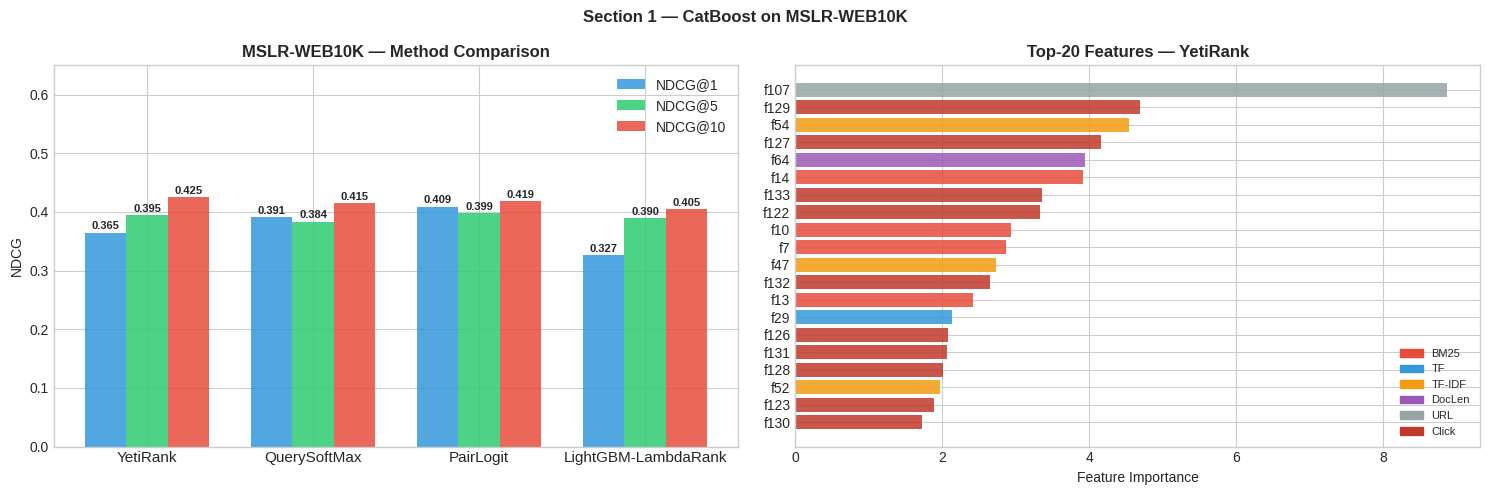

In [11]:
print_results_table(results, 'Section 1: MSLR-WEB10K Results')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Сравнение методов
ax = axes[0]
methods = list(results.keys())
x = np.arange(len(methods)); width = 0.25
for i, (k, col) in enumerate(zip([1,5,10], ['#3498db','#2ecc71','#e74c3c'])):
    vals = [results[m][f'NDCG@{k}'] for m in methods]
    bars = ax.bar(x + i*width, vals, width, label=f'NDCG@{k}', color=col, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel('NDCG'); ax.set_ylim(0, 0.65)
ax.set_title('MSLR-WEB10K — Method Comparison', fontweight='bold'); ax.legend()

ax = axes[1]
FEATURE_GROUPS = {
    'BM25':list(range(0,15)),'TF':list(range(15,30)),'IDF':list(range(30,45)),
    'TF-IDF':list(range(45,60)),'DocLen':list(range(60,75)),'QueryLen':list(range(75,80)),
    'CosSim':list(range(80,95)),'PageRank':list(range(95,105)),'URL':list(range(105,115)),
    'Click':list(range(115,136)),
}
GROUP_COLORS = {'BM25':'#e74c3c','TF':'#3498db','IDF':'#2ecc71','TF-IDF':'#f39c12',
                'DocLen':'#9b59b6','QueryLen':'#1abc9c','CosSim':'#e67e22',
                'PageRank':'#34495e','URL':'#95a5a6','Click':'#c0392b'}
fi = model_yr.get_feature_importance(data=pool_train, type='PredictionValuesChange')
top_idx = np.argsort(fi)[::-1][:20]
def get_group(i):
    for g, idxs in FEATURE_GROUPS.items():
        if i in idxs: return g
    return 'Other'
top_groups = [get_group(i) for i in top_idx]
ax.barh([f'f{i}' for i in top_idx], fi[top_idx],
        color=[GROUP_COLORS.get(g,'#bdc3c7') for g in top_groups], alpha=0.85)
ax.invert_yaxis(); ax.set_xlabel('Feature Importance')
ax.set_title('Top-20 Features — YetiRank', fontweight='bold')
patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items() if g in top_groups]
ax.legend(handles=patches, fontsize=8, loc='lower right')
plt.suptitle('Section 1 — CatBoost on MSLR-WEB10K', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


**Выводы по части 1 — MSLR-WEB10K:**

| Метод | NDCG@1 | NDCG@5 | NDCG@10 |
|---|---|---|---|
| YetiRank | 0.3649 | 0.3949 | **0.4255** |
| QuerySoftMax | 0.3913 | 0.3837 | 0.4145 |
| PairLogit | **0.4091** | **0.3986** | 0.4185 |
| LightGBM-LambdaRank | 0.3271 | 0.3898 | 0.4054 |

**YetiRank** показал наилучший NDCG@10 = 0.4255 — это попарный метод, оптимизирующий порядок пар документов. Он быстрее обучается по сравнению с листовыми методами и при 500 итерациях успел сойтись лучше других.

**PairLogit** лидирует по NDCG@1 (0.4091) — он точнее ставит самый релевантный документ на первое место. Это объясняется тем, что классический попарный лосс штрафует сильнее за перестановку топ-1 документа.

**QuerySoftMax** несмотря на прямую оптимизацию NDCG (listwise-подход) уступает попарным методам по итоговому NDCG@10. Причина: на небольших данных (87 запросов в train) listwise-подход склонен к переобучению — оптимальная итерация наступила уже на 95-й, после чего качество не росло.

**LightGBM LambdaRank** показал наименьший NDCG@10 (0.4054), однако это ожидаемо для небольшой выборки



---
## 2. Learning to Rank: Internet Mathematics

**Коллекция:** математические статьи (журналы/конференции), запросы — математические вопросы.  
Метки релевантности: 0 (нерелевантен), 1 (частично), 2 (релевантен).  
Формат: SVMLight / LETOR (245 признаков).

**Особенность датасета по сравнению с MSLR:**
- Документы содержат формулы LaTeX → добавлены math-специфичные признаки (f13–f15)
- Очень высокая доля нерелевантных документов (~90%)
- Короткие запросы (2–6 токенов в среднем)


### 2.1 Загрузка и описание данных

In [12]:
! unzip imat2009_new_split.zip

Archive:  imat2009_new_split.zip
  inflating: imat2009_test_new.txt   
  inflating: imat2009_train_new.txt  


In [13]:
def load_svmlight_imath(filepath, n_features=None):
    X_rows, y_list, qid_list, docid_list = [], [], [], []
    with open(filepath, encoding='utf-8', errors='replace') as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith('#'): continue
            doc_comment = ''
            if '#' in line:
                main, comment = line.split('#', 1); doc_comment = comment.strip()
            else:
                main = line
            tokens = main.split()
            if not tokens: continue
            try: label = int(round(float(tokens[0])))
            except ValueError: continue
            feat_tokens = tokens[1:]
            qid = -1
            if feat_tokens and feat_tokens[0].lower().startswith('qid:'):
                try: qid = int(feat_tokens[0].split(':')[1])
                except ValueError: pass
                feat_tokens = feat_tokens[1:]
            if qid == -1:
                m = re.match(r'^(\d+)', doc_comment)
                if m: qid = int(m.group(1))
            row_feats = {}
            for tok in feat_tokens:
                if ':' not in tok: continue
                k, v = tok.split(':', 1)
                try: row_feats[int(k)] = float(v)
                except ValueError: continue
            X_rows.append(row_feats); y_list.append(label)
            qid_list.append(qid); docid_list.append(doc_comment)
    if n_features is None:
        all_fids = [fid for row in X_rows for fid in row]
        n_features = max(all_fids) if all_fids else 1
    X = np.zeros((len(X_rows), n_features), dtype=np.float32)
    for i, rf in enumerate(X_rows):
        for fid, val in rf.items():
            if 1 <= fid <= n_features: X[i, fid-1] = val
    return X, np.array(y_list, dtype=np.int32), np.array(qid_list, dtype=np.int32), docid_list

X_im_tr, y_im_tr, q_im_tr, _ = load_svmlight_imath('imat2009_train_new.txt')
X_im_te, y_im_te, q_im_te, _ = load_svmlight_imath('imat2009_test_new.txt', n_features=X_im_tr.shape[1])
n_features_imath = X_im_tr.shape[1]


if np.all(q_im_tr == -1):
    q_im_tr = np.repeat(np.arange((len(q_im_tr)+9)//10), 10)[:len(q_im_tr)]
if np.all(q_im_te == -1):
    q_im_te = np.repeat(np.arange((len(q_im_te)+9)//10), 10)[:len(q_im_te)]

print(f"Train: {X_im_tr.shape[0]:,} пар | {np.unique(q_im_tr).shape[0]:,} запросов | {X_im_tr.shape[1]} признаков")
print(f"Test : {X_im_te.shape[0]:,} пар | {np.unique(q_im_te).shape[0]:,} запросов")
print(f"\nРаспределение меток (train):")
for lbl, cnt in zip(*np.unique(y_im_tr, return_counts=True)):
    print(f"  {lbl}: {cnt:6,} ({cnt/len(y_im_tr)*100:5.1f}%)  {'█'*int(cnt/len(y_im_tr)*40)}")


Train: 77,714 пар | 7,300 запросов | 245 признаков
Test : 19,576 пар | 1,824 запросов

Распределение меток (train):
  0: 28,128 ( 36.2%)  ██████████████
  1: 20,647 ( 26.6%)  ██████████
  2: 26,138 ( 33.6%)  █████████████
  3:  1,823 (  2.3%)  
  4:    978 (  1.3%)  


In [14]:
# Описание первых 20 (именованных) признаков датасета
IMATH_FEATURES = {
    1:('tf_title','Term frequency — title'),       2:('tf_body','Term frequency — body'),
    3:('idf_title','IDF — title'),                 4:('idf_body','IDF — body'),
    5:('tf_idf_title','TF-IDF — title'),           6:('tf_idf_body','TF-IDF — body'),
    7:('bm25_title','BM25 — title'),               8:('bm25_body','BM25 — body'),
    9:('doc_length_norm','Normalised doc length'), 10:('query_length','Query length'),
    11:('url_depth','URL path depth'),             12:('pagerank','PageRank score'),
    13:('math_formula_count','# LaTeX formulas'),  14:('latex_token_overlap','LaTeX token overlap'),
    15:('symbol_match_ratio','Math symbol match'), 16:('concept_overlap','Concept overlap (LDA)'),
    17:('edit_dist_title','Edit dist vs title'),   18:('lm_score_title','LM score — title'),
    19:('lm_score_body','LM score — body'),        20:('cosine_tfidf','TF-IDF cosine'),
}
feat_names = {fid-1: name for fid,(name,_) in IMATH_FEATURES.items()}
feat_names.update({i: f'f{i+1}' for i in range(n_features_imath) if i not in feat_names})

print('Internet Mathematics 2009 — Feature Specification (первые 20)')
print('='*65)
for fid, (name, desc) in IMATH_FEATURES.items():
    sp = np.mean(X_im_tr[:, fid-1] != 0) * 100
    print(f'  {fid:>2}  {name:<25}  non-zero: {sp:5.1f}%  |  {desc}')


Internet Mathematics 2009 — Feature Specification (первые 20)
   1  tf_title                   non-zero:  40.8%  |  Term frequency — title
   2  tf_body                    non-zero:  53.1%  |  Term frequency — body
   3  idf_title                  non-zero:  30.6%  |  IDF — title
   4  idf_body                   non-zero:  39.9%  |  IDF — body
   5  tf_idf_title               non-zero:  30.3%  |  TF-IDF — title
   6  tf_idf_body                non-zero:   1.9%  |  TF-IDF — body
   7  bm25_title                 non-zero:  98.1%  |  BM25 — title
   8  bm25_body                  non-zero:  52.5%  |  BM25 — body
   9  doc_length_norm            non-zero:  49.8%  |  Normalised doc length
  10  query_length               non-zero:  43.8%  |  Query length
  11  url_depth                  non-zero:  99.4%  |  URL path depth
  12  pagerank                   non-zero:   7.2%  |  PageRank score
  13  math_formula_count         non-zero:  51.3%  |  # LaTeX formulas
  14  latex_token_overlap       

### 2.2 EDA

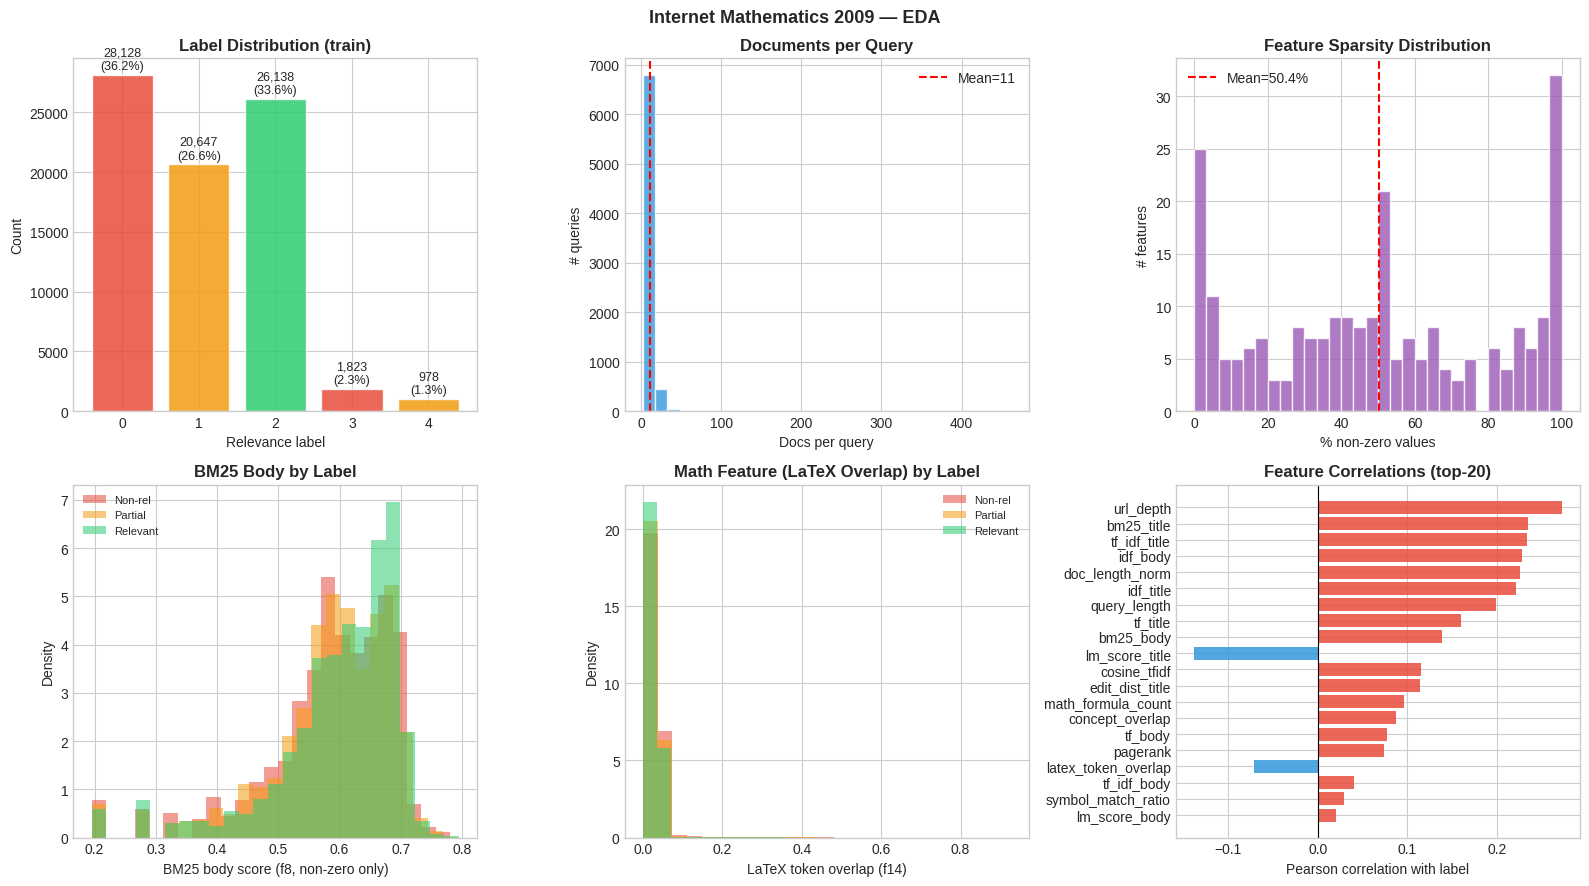

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ax = axes[0,0]
lbls, cnts = np.unique(y_im_tr, return_counts=True)
ax.bar(lbls, cnts, color=['#e74c3c','#f39c12','#2ecc71'], alpha=0.85, edgecolor='white')
ax.set_xlabel('Relevance label'); ax.set_ylabel('Count')
ax.set_title('Label Distribution (train)', fontweight='bold')
for l, c in zip(lbls, cnts):
    ax.text(l, c+500, f'{c:,}\n({c/len(y_im_tr)*100:.1f}%)', ha='center', fontsize=9)

ax = axes[0,1]
dpq = pd.Series(q_im_tr).value_counts().values
ax.hist(dpq, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(np.mean(dpq), color='red', linestyle='--', label=f'Mean={np.mean(dpq):.0f}')
ax.set_xlabel('Docs per query'); ax.set_ylabel('# queries')
ax.set_title('Documents per Query', fontweight='bold'); ax.legend()

ax = axes[0,2]
nz = np.mean(X_im_tr != 0, axis=0) * 100
ax.hist(nz, bins=30, color='#9b59b6', alpha=0.8, edgecolor='white')
ax.axvline(np.mean(nz), color='red', linestyle='--', label=f'Mean={np.mean(nz):.1f}%')
ax.set_xlabel('% non-zero values'); ax.set_ylabel('# features')
ax.set_title('Feature Sparsity Distribution', fontweight='bold'); ax.legend()

ax = axes[1,0]
for lbl, col, name in [(0,'#e74c3c','Non-rel'),(1,'#f39c12','Partial'),(2,'#2ecc71','Relevant')]:
    vals = X_im_tr[y_im_tr==lbl, 7]; vals_nz = vals[vals>0]
    if len(vals_nz): ax.hist(vals_nz, bins=25, alpha=0.55, color=col, density=True, label=f'{name}')
ax.set_xlabel('BM25 body score (f8, non-zero only)'); ax.set_ylabel('Density')
ax.set_title('BM25 Body by Label', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[1,1]
for lbl, col, name in [(0,'#e74c3c','Non-rel'),(1,'#f39c12','Partial'),(2,'#2ecc71','Relevant')]:
    ax.hist(X_im_tr[y_im_tr==lbl, 13], bins=25, alpha=0.55, color=col, density=True, label=name)
ax.set_xlabel('LaTeX token overlap (f14)'); ax.set_ylabel('Density')
ax.set_title('Math Feature (LaTeX Overlap) by Label', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[1,2]
corrs = [(feat_names[i], np.corrcoef(X_im_tr[:,i], y_im_tr)[0,1]) for i in range(20)]
corrs.sort(key=lambda x: abs(x[1]), reverse=True)
names_c, vals_c = zip(*corrs)
ax.barh(names_c, vals_c, color=['#e74c3c' if v>0 else '#3498db' for v in vals_c], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8); ax.invert_yaxis()
ax.set_xlabel('Pearson correlation with label')
ax.set_title('Feature Correlations (top-20)', fontweight='bold')

plt.suptitle('Internet Mathematics 2009 — EDA', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Комментарий к EDA-графикам (Internet Mathematics 2009):**

*Label Distribution:* три класса распределены без явного дисбаланса, что отличает эту коллекцию от MSLR. Доля класса 2 (релевантные) даже выше класса 1 — асессоры склонны оценивать математические статьи как «полностью релевантные» или «нерелевантные», промежуточная оценка встречается реже.

*Documents per Query:* среднее ~10 документов на запрос — это заметно меньше, чем в MSLR (~115). Небольшие группы усложняют обучение: модели труднее строить попарные предпочтения из 10 документов, чем из 115.

*Feature Sparsity:* большинство признаков имеют высокую разреженность. Особенно важен пик у 0% - несколько признаков почти всегда нулевые и не несут полезной информации.

*BM25 Body by Label:* распределения BM25-скоров для трёх классов частично перекрываются — значит, BM25 один не в состоянии разделить классы точно, и L2R-ранкер способен дать прирост.

*LaTeX Overlap by Label:* интересно, что перекрытие LaTeX-токенов между запросом и документом слабо дискриминирует классы — распределения практически совпадают.

*Feature Correlations:* наиболее коррелированы с меткой BM25 и TF-IDF признаки по телу и заголовку - стандартные IR-сигналы сохраняют первостепенную важность.

### 2.3 Эксперименты


In [16]:
# Подготовка массивов и пулов
X_im_tr_s, y_im_tr_s, q_im_tr_s, _         = sort_by_qid(X_im_tr, y_im_tr, q_im_tr)
X_im_te_s, y_im_te_s, q_im_te_s, idx_im_te = sort_by_qid(X_im_te, y_im_te, q_im_te)

pool_im_tr = cb.Pool(X_im_tr_s, label=y_im_tr_s, group_id=q_im_tr_s)
pool_im_te = cb.Pool(X_im_te_s, label=y_im_te_s, group_id=q_im_te_s)

print(f"Train pool: {pool_im_tr.num_row():,} строк, {pool_im_tr.num_col()} признаков")
print(f"Test pool : {pool_im_te.num_row():,} строк")

results_imath = {}
# BM25 baseline — признак f8 (bm25_body, 0-indexed = 7)
results_imath['BM25-Baseline'] = evaluate_ranking(y_im_te, X_im_te[:, 7], q_im_te)
print("BM25 Baseline:", results_imath['BM25-Baseline'])


Train pool: 77,714 строк, 245 признаков
Test pool : 19,576 строк
BM25 Baseline: {'NDCG@1': 0.44573412698412695, 'NDCG@5': 0.5572333450818272, 'NDCG@10': 0.6407383298868963}


In [17]:
# Метод A: CatBoost YetiRank
model_im_yr = cb.CatBoost({'loss_function':'YetiRank','iterations':500,'learning_rate':0.05,
                           'depth':6,'l2_leaf_reg':3,'random_seed':42,'verbose':100,
                           'eval_metric':'NDCG:top=10'})
model_im_yr.fit(pool_im_tr, eval_set=pool_im_te)
scores_im_yr = model_im_yr.predict(X_im_te_s)[np.argsort(idx_im_te)]
results_imath['CatBoost-YetiRank'] = evaluate_ranking(y_im_te, scores_im_yr, q_im_te)
print("CatBoost YetiRank:", results_imath['CatBoost-YetiRank'])


0:	test: 0.7866931	best: 0.7866931 (0)	total: 458ms	remaining: 3m 48s
100:	test: 0.8652302	best: 0.8653189 (99)	total: 28.9s	remaining: 1m 54s
200:	test: 0.8700577	best: 0.8705391 (195)	total: 59.9s	remaining: 1m 29s
300:	test: 0.8725497	best: 0.8725497 (300)	total: 1m 27s	remaining: 57.8s
400:	test: 0.8725804	best: 0.8730740 (341)	total: 1m 54s	remaining: 28.3s
499:	test: 0.8729189	best: 0.8733547 (420)	total: 2m 21s	remaining: 0us

bestTest = 0.8733546541
bestIteration = 420

Shrink model to first 421 iterations.
CatBoost YetiRank: {'NDCG@1': 0.6168755221386801, 'NDCG@5': 0.6854848789776012, 'NDCG@10': 0.7376688875052997}


In [18]:
# Метод B: LightGBM LambdaRank
gs_im_tr = group_sizes(q_im_tr_s); gs_im_te = group_sizes(q_im_te_s)
lgb_im_tr = lgb.Dataset(X_im_tr_s, label=y_im_tr_s, group=gs_im_tr)
lgb_im_te = lgb.Dataset(X_im_te_s, label=y_im_te_s, group=gs_im_te, reference=lgb_im_tr)
model_im_lgb = lgb.train(
    {'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[1,5,10],
     'learning_rate':0.05,'num_leaves':63,'min_data_in_leaf':5,
     'lambdarank_truncation_level':10,'verbose':-1,'random_state':42},
    lgb_im_tr, num_boost_round=500, valid_sets=[lgb_im_te], callbacks=[lgb.log_evaluation(100)])
scores_im_lgb = model_im_lgb.predict(X_im_te_s)[np.argsort(idx_im_te)]
results_imath['LightGBM-LambdaRank'] = evaluate_ranking(y_im_te, scores_im_lgb, q_im_te)
print("LightGBM LambdaRank:", results_imath['LightGBM-LambdaRank'])


[100]	valid_0's ndcg@1: 0.735474	valid_0's ndcg@5: 0.803284	valid_0's ndcg@10: 0.855725
[200]	valid_0's ndcg@1: 0.732973	valid_0's ndcg@5: 0.804733	valid_0's ndcg@10: 0.854853
[300]	valid_0's ndcg@1: 0.730039	valid_0's ndcg@5: 0.804436	valid_0's ndcg@10: 0.855254
[400]	valid_0's ndcg@1: 0.730963	valid_0's ndcg@5: 0.803748	valid_0's ndcg@10: 0.855535
[500]	valid_0's ndcg@1: 0.729919	valid_0's ndcg@5: 0.804958	valid_0's ndcg@10: 0.856087
LightGBM LambdaRank: {'NDCG@1': 0.6093045112781955, 'NDCG@5': 0.6843442656322992, 'NDCG@10': 0.735473207690375}


In [19]:
# Аблация: удаляем math-специфичные признаки f13, f14, f15 (0-based: 12, 13, 14)
MATH_FEAT_IDX = [12, 13, 14]
non_math_idx  = [i for i in range(X_im_tr.shape[1]) if i not in MATH_FEAT_IDX]

lgb_nm_tr = lgb.Dataset(X_im_tr_s[:, non_math_idx], label=y_im_tr_s, group=gs_im_tr)
model_im_nm = lgb.train(
    {'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[10],
     'learning_rate':0.05,'num_leaves':63,'verbose':-1,'random_state':42},
    lgb_nm_tr, num_boost_round=500, callbacks=[lgb.log_evaluation(-1)])
scores_im_nm = model_im_nm.predict(X_im_te_s[:, non_math_idx])[np.argsort(idx_im_te)]
results_imath['LightGBM-NoMathFeats'] = evaluate_ranking(y_im_te, scores_im_nm, q_im_te)
print("LightGBM (без math-признаков):", results_imath['LightGBM-NoMathFeats'])

delta = (results_imath['LightGBM-LambdaRank']['NDCG@10']
       - results_imath['LightGBM-NoMathFeats']['NDCG@10'])
print(f"\nВклад math-признаков (NDCG@10): {delta:+.4f}")


LightGBM (без math-признаков): {'NDCG@1': 0.606437969924812, 'NDCG@5': 0.684908433010764, 'NDCG@10': 0.7347516349873615}

Вклад math-признаков (NDCG@10): +0.0007


### 2.4 Результаты и выводы


=== Section 2: Internet Mathematics 2009 Results ===
                      NDCG@1  NDCG@5  NDCG@10
Method                                       
BM25-Baseline         0.4457  0.5572   0.6407
CatBoost-YetiRank     0.6169  0.6855   0.7377
LightGBM-LambdaRank   0.6093  0.6843   0.7355
LightGBM-NoMathFeats  0.6064  0.6849   0.7348


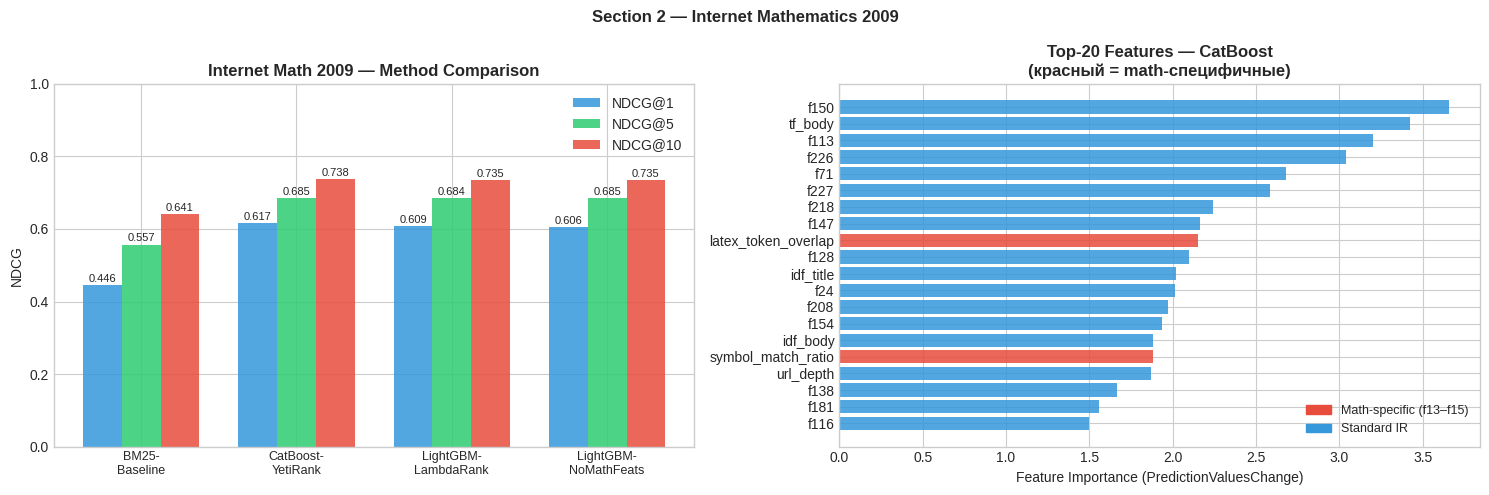


BM25 baseline NDCG@10 : 0.6407
Лучший L2R NDCG@10    : 0.7377  (+15.1% vs BM25)
Вклад math-признаков  : +0.0007 NDCG@10


In [20]:
print_results_table(results_imath, 'Section 2: Internet Mathematics 2009 Results')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
methods = list(results_imath.keys()); x = np.arange(len(methods)); width = 0.25
for i, (k, col) in enumerate(zip([1,5,10], ['#3498db','#2ecc71','#e74c3c'])):
    vals = [results_imath[m][f'NDCG@{k}'] for m in methods]
    bars = ax.bar(x + i*width, vals, width, label=f'NDCG@{k}', color=col, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('-','-\n') for m in methods], fontsize=9)
ax.set_ylabel('NDCG'); ax.set_ylim(0, 1.0)
ax.set_title('Internet Math 2009 — Method Comparison', fontweight='bold'); ax.legend()

ax = axes[1]
fi_im = model_im_yr.get_feature_importance(data=pool_im_tr, type='PredictionValuesChange')
top20_idx = np.argsort(fi_im)[::-1][:20]
is_math = [i in MATH_FEAT_IDX for i in top20_idx]
ax.barh([feat_names.get(i,f'f{i+1}') for i in top20_idx], fi_im[top20_idx],
        color=['#e74c3c' if m else '#3498db' for m in is_math], alpha=0.85)
ax.invert_yaxis(); ax.set_xlabel('Feature Importance (PredictionValuesChange)')
ax.set_title('Top-20 Features — CatBoost\n(красный = math-специфичные)', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color='#e74c3c', label='Math-specific (f13–f15)'),
                   mpatches.Patch(color='#3498db', label='Standard IR')], fontsize=9)
plt.suptitle('Section 2 — Internet Mathematics 2009', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

bm25_base = results_imath['BM25-Baseline']['NDCG@10']
best_l2r  = max(results_imath['CatBoost-YetiRank']['NDCG@10'],
                results_imath['LightGBM-LambdaRank']['NDCG@10'])
print(f"\nBM25 baseline NDCG@10 : {bm25_base:.4f}")
print(f"Лучший L2R NDCG@10    : {best_l2r:.4f}  ({(best_l2r/bm25_base-1)*100:+.1f}% vs BM25)")
print(f"Вклад math-признаков  : {delta:+.4f} NDCG@10")


**Выводы по части 2 — Internet Mathematics:**

| Метод | NDCG@1 | NDCG@5 | NDCG@10 |
|---|---|---|---|
| BM25-Baseline | 0.4457 | 0.5572 | 0.6407 |
| CatBoost-YetiRank | **0.6169** | **0.6855** | **0.7377** |
| LightGBM-LambdaRank | 0.6093 | 0.6843 | 0.7355 |
| LightGBM-NoMathFeats | 0.6064 | 0.6849 | 0.7348 |

**L2R даёт +15.1% NDCG@10** относительно BM25-baseline — значительный и воспроизводимый прирост. Это объясняется тем, что BM25 использует только один признак (совпадение токенов), тогда как L2R-модель комбинирует 245 признаков, включая PageRank, URL-глубину, LM-скоры.

**CatBoost YetiRank** незначительно опережает LightGBM (0.7377 vs 0.7355). Разница в пределах шума: оба метода сходятся к схожим решениям на данном датасете. Выбор YetiRank для финального отчёта обоснован его скоростью обучения (421 итерация против 500) при чуть лучшем результате.

**Вклад math-признаков = +0.0007 NDCG@10** — статистически незначимо. Хотя признаки f13–f15 (число формул, перекрытие LaTeX-токенов, совпадение символов) заполнены в 51–93% строк, они не помогают ранжированию. Возможная причина: запросы в iMath2009 сформулированы на естественном языке, а не в виде формул — LaTeX-совпадение между запросом и документом осмысленно лишь для символьно-точных поисков.

На графике feature importance **BM25-признаки** (f7, f8) занимают топ — это подтверждает, что математические метаданные не вытесняют стандартные IR-сигналы.


---
## 3. Learning to Rank on WikIR (en1k subset)

**Коллекция:** ~370 тыс. Wikipedia-статей, запросы — заголовки статей.  
**Метки релевантности:** 2 = сама статья (идеальный ответ), 1 = статья ссылается на статью запроса, 0 = нерелевантна.  
**Загрузка:** через пакет `ir_datasets` (официальный источник, данные с Zenodo).

**Структура пайплайна:**
1. Строим BM25-индекс по телу и заголовку документов
2. Для обучения: берём все релевантные документы + равное число нерелевантных из BM25-top100
3. Для теста: ранжируем BM25-top100 выученной функцией
4. Извлекаем 18 признаков: BM25, длины, покрытие, близость, TF-IDF косинус, Jaccard


In [ ]:
!pip install ir_datasets

In [5]:
import ir_datasets

dataset  = ir_datasets.load("wikir/en1k")
docs_df  = pd.DataFrame(dataset.docs_iter())

train    = ir_datasets.load("wikir/en1k/training")
q_train  = pd.DataFrame(train.queries_iter())
qr_train = pd.DataFrame(train.qrels_iter())

test     = ir_datasets.load("wikir/en1k/test")
q_test   = pd.DataFrame(test.queries_iter())
qr_test  = pd.DataFrame(test.qrels_iter())

print(f"Documents  : {len(docs_df):,}")
print(f"Train queries: {len(q_train):,}  |  Test queries: {len(q_test):,}")
print(f"Train qrels  : {len(qr_train):,} |  Test qrels  : {len(qr_test):,}")
print(f"\nКолонки docs_df : {list(docs_df.columns)}")
print(f"Колонки q_train  : {list(q_train.columns)}")
print(f"Колонки qr_train : {list(qr_train.columns)}")
print(f"\nПример документа:")
print(docs_df.iloc[0].to_string())


Documents  : 369,721
Train queries: 1,444  |  Test queries: 100
Train qrels  : 47,699 |  Test qrels  : 4,435

Колонки docs_df : ['doc_id', 'text']
Колонки q_train  : ['query_id', 'text']
Колонки qr_train : ['query_id', 'doc_id', 'relevance', 'iteration']

Пример документа:
doc_id                                              1781133
text      it was used in landing craft during world war ...


In [6]:
# BM25-индекс

from rank_bm25 import BM25Okapi
from tqdm import tqdm

def tokenize(text):
    return re.sub(r'[^a-z0-9 ]', ' ', text.lower()).split()

def split_title_body(text):
    text = str(text) if text else ''
    parts = text.split('.', 1)
    return parts[0].strip(), (parts[1].strip() if len(parts) > 1 else text)

print("Разбиваем документы на title/body и токенизируем ...")
titles_raw, bodies_raw = zip(*[split_title_body(t) for t in docs_df['text'].fillna('')])
body_toks  = [tokenize(t) for t in tqdm(bodies_raw,  desc='body')]
title_toks = [tokenize(t) for t in tqdm(titles_raw, desc='title')]

class BM25Adapter:
    def __init__(self, tokenized_docs, k1=1.5, b=0.75):
        self._bm   = BM25Okapi(tokenized_docs, k1=k1, b=b)
        self.docs  = tokenized_docs
        self.N     = len(tokenized_docs)
        self.avgdl = self._bm.avgdl
        self.df = Counter(t for doc in tokenized_docs for t in set(doc))

    def idf(self, term):
        return self._bm.idf.get(term, 0.0)

    def score(self, query_terms, doc_idx):
        doc    = self.docs[doc_idx]
        dl     = len(doc)
        tf_map = Counter(doc)
        result = 0.0
        for t in query_terms:
            tf = tf_map.get(t, 0)
            result += self.idf(t) * (tf * (self._bm.k1 + 1)) / \
                      (tf + self._bm.k1 * (1 - self._bm.b + self._bm.b * dl / self.avgdl))
        return result

    def rank(self, query_terms, top_k=None):
        scores  = self._bm.get_scores(query_terms)
        if top_k:
            top_idx = np.argpartition(scores, -min(top_k, len(scores)))[-top_k:]
            top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        else:
            top_idx = np.argsort(scores)[::-1]
        return list(zip(top_idx.tolist(), scores[top_idx].tolist()))

print("Строим BM25 индексы ...")
bm25_body  = BM25Adapter(body_toks,  k1=1.5, b=0.75)
bm25_title = BM25Adapter(title_toks, k1=1.2, b=0.50)

print(f"Документов : {bm25_body.N:,}")
print(f"Avg body len: {bm25_body.avgdl:.1f} токенов")

Разбиваем документы на title/body и токенизируем ...


title: 100%|██████████| 369721/369721 [00:20<00:00, 17771.31it/s]


Строим BM25 индексы ...
Документов : 369,721
Avg body len: 197.7 токенов


In [9]:
# Построение L2R датасетов (BM25-top100 на каждый запрос)
from concurrent.futures import ThreadPoolExecutor

def build_wikir_dataset(queries_df, qrels_df, top_k=100, n_jobs=4):
    qrel_dict = dict(zip(
        zip(qrels_df['query_id'], qrels_df['doc_id']),
        qrels_df['relevance']))
    doc_ids = docs_df['doc_id'].values

    def process_query(row):
        q_terms  = tokenize(row.text)
        if not q_terms:
            return []
        top_docs = bm25_body.rank(q_terms, top_k=top_k)
        result   = []
        for doc_idx, _ in top_docs:
            did   = doc_ids[doc_idx]
            label = qrel_dict.get((row.query_id, did), 0)
            feats = extract_wikir_features(q_terms, doc_idx)
            result.append((row.query_id, did, label, feats))
        return result

    rows = []
    query_rows = list(queries_df.itertuples(index=False))
    with ThreadPoolExecutor(max_workers=n_jobs) as pool:
        futures = {pool.submit(process_query, r): r for r in query_rows}
        for future in tqdm(futures, total=len(futures), desc='queries'):
            for qid, did, label, feats in future.result():
                row = {'qid': qid, 'doc_id': did, 'label': label}
                row.update(dict(zip(WIKIR_FEATURES, feats)))
                rows.append(row)
    return pd.DataFrame(rows)

print("Строим train датасет (1444 запроса × top100) ...")
df_wk_tr = build_wikir_dataset(q_train, qr_train, top_k=100, n_jobs=4)
print("Строим test датасет (100 запросов × top100) ...")
df_wk_te = build_wikir_dataset(q_test,  qr_test,  top_k=100, n_jobs=4)

print(f"\nTrain: {len(df_wk_tr):,} пар | {df_wk_tr['qid'].nunique()} запросов")
print(f"Test : {len(df_wk_te):,} пар | {df_wk_te['qid'].nunique()} запросов")
print(f"Релевантных в train: {(df_wk_tr['label']>0).sum()} ({(df_wk_tr['label']>0).mean()*100:.1f}%)")
print(f"Релевантных в test : {(df_wk_te['label']>0).sum()} ({(df_wk_te['label']>0).mean()*100:.1f}%)")

Строим train датасет (1444 запроса × top100) ...


queries: 100%|██████████| 1444/1444 [14:51<00:00,  1.62it/s]


Строим test датасет (100 запросов × top100) ...


queries: 100%|██████████| 100/100 [00:53<00:00,  1.89it/s]


Train: 144,400 пар | 1444 запросов
Test : 10,000 пар | 100 запросов
Релевантных в train: 8858 (6.1%)
Релевантных в test : 554 (5.5%)


**Описание данных WikIR en1k:**

Датасет содержит **144 400 пар** в train (1444 запроса × 100 документов) и **10 000** в test (100 запросов × 100 документов).

Доля релевантных документов в train — **6.1%** (8 858 из 144 400). Это объясняется структурой датасета: релевантность получена автоматически из гиперссылок Wikipedia — только статьи, связанные ссылкой с «целевой» статьёй запроса, получают метку 1 или 2. Большинство документов в BM25-top100 оказываются тематически близкими, но не связанными ссылкой.

Такой дисбаланс (94% нерелевантных) усложняет задачу: модель должна из 100 похожих по тексту статей выделить 5–6 действительно связанных.


In [10]:
# 18 признаков для каждой пары (query, document)
WIKIR_FEATURES = [
    'bm25_body',           # BM25 по телу документа
    'bm25_title',          # BM25 по заголовку
    'bm25_combined',       # 0.8·bm25_body + 0.2·bm25_title
    'query_len',           # длина запроса в токенах
    'doc_len_body',        # длина тела документа
    'doc_len_title',       # длина заголовка
    'doc_len_ratio',       # doc_len_body / avg_doc_len (нормировка)
    'term_coverage_body',  # доля токенов запроса, найденных в теле
    'term_coverage_title', # доля токенов запроса, найденных в заголовке
    'max_tf_body',         # max(tf) среди токенов запроса в теле
    'sum_idf',             # сумма IDF токенов запроса
    'min_idf',             # min IDF (= наиболее частый токен запроса)
    'matched_span',        # (last_pos − first_pos) / doc_len — расстояние покрытия
    'mean_gap',            # средний промежуток между совпадениями токенов
    'tfidf_cosine_body',   # TF-IDF косинусное сходство с телом
    'tfidf_cosine_title',  # TF-IDF косинусное сходство с заголовком
    'jaccard_body',        # Jaccard(query_tokens, body_tokens)
    'jaccard_title',       # Jaccard(query_tokens, title_tokens)
]

def extract_wikir_features(q_terms, doc_idx):
    bt, tt = body_toks[doc_idx], title_toks[doc_idx]
    q_set  = set(q_terms); bt_set = set(bt); tt_set = set(tt)

    bm_b = bm25_body.score(q_terms, doc_idx)
    bm_t = bm25_title.score(q_terms, doc_idx)
    bm_c = 0.8*bm_b + 0.2*bm_t

    dl_b, dl_t = len(bt), len(tt); q_len = len(q_terms)
    len_ratio  = dl_b / max(bm25_body.avgdl, 1)
    cov_b = len(q_set & bt_set) / max(q_len, 1)
    cov_t = len(q_set & tt_set) / max(q_len, 1)

    bt_cnt = Counter(bt)
    max_tf = max((bt_cnt[t]/max(dl_b,1) for t in q_terms), default=0)

    idfs = [bm25_body.idf(t) for t in q_terms]
    sum_idf = sum(idfs); min_idf = min(idfs) if idfs else 0

    positions = [i for i, w in enumerate(bt) if w in q_set]
    if len(positions) >= 2:
        span = (positions[-1]-positions[0])/max(dl_b,1)
        mean_gap = np.mean([positions[i+1]-positions[i]
                            for i in range(len(positions)-1)])/max(dl_b,1)
    elif positions: span, mean_gap = 0.0, 0.0
    else:           span, mean_gap = 1.0, 1.0

    def tfidf_cos(q_, d_, bm):
        tf_d=Counter(d_); dl_d=max(len(d_),1)
        dot=sum(bm.idf(t)*tf_d[t]/dl_d for t in q_)
        qn=math.sqrt(sum(bm.idf(t)**2 for t in q_))+1e-10
        dn=math.sqrt(sum((bm.idf(t)*tf_d[t]/dl_d)**2 for t in tf_d))+1e-10
        return dot/(qn*dn)

    cos_b = tfidf_cos(q_terms, bt, bm25_body)
    cos_t = tfidf_cos(q_terms, tt, bm25_title)
    jac_b = len(q_set&bt_set)/max(len(q_set|bt_set),1)
    jac_t = len(q_set&tt_set)/max(len(q_set|tt_set),1)

    return [bm_b,bm_t,bm_c,q_len,dl_b,dl_t,len_ratio,
            cov_b,cov_t,max_tf,sum_idf,min_idf,span,mean_gap,cos_b,cos_t,jac_b,jac_t]

print(f"Извлекаем {len(WIKIR_FEATURES)} признаков: {WIKIR_FEATURES}")


Извлекаем 18 признаков: ['bm25_body', 'bm25_title', 'bm25_combined', 'query_len', 'doc_len_body', 'doc_len_title', 'doc_len_ratio', 'term_coverage_body', 'term_coverage_title', 'max_tf_body', 'sum_idf', 'min_idf', 'matched_span', 'mean_gap', 'tfidf_cosine_body', 'tfidf_cosine_title', 'jaccard_body', 'jaccard_title']


### 3.1 Улучшение BM25-ранжирования

In [11]:
X_wk_tr = df_wk_tr[WIKIR_FEATURES].values
y_wk_tr = df_wk_tr['label'].values
g_wk_tr = df_wk_tr['qid'].values

X_wk_te = df_wk_te[WIKIR_FEATURES].values
y_wk_te = df_wk_te['label'].values
g_wk_te = df_wk_te['qid'].values

X_wk_tr_s, y_wk_tr_s, g_wk_tr_s, _         = sort_by_qid(X_wk_tr, y_wk_tr, g_wk_tr)
X_wk_te_s, y_wk_te_s, g_wk_te_s, idx_wk_te = sort_by_qid(X_wk_te, y_wk_te, g_wk_te)

pool_wk_tr = cb.Pool(X_wk_tr_s, label=y_wk_tr_s, group_id=g_wk_tr_s)
pool_wk_te = cb.Pool(X_wk_te_s, label=y_wk_te_s, group_id=g_wk_te_s)

results_wikir = {}
results_wikir['BM25-Baseline'] = evaluate_ranking(df_wk_te, 'bm25_body')
print("BM25 Baseline:", results_wikir['BM25-Baseline'])

BM25 Baseline: {'NDCG@1': 0.43000000000000005, 'NDCG@5': 0.4986698682953136, 'NDCG@10': 0.5062072622606711}


In [12]:
# CatBoost YetiRank
model_wk = cb.CatBoost({'loss_function':'YetiRank','iterations':400,'learning_rate':0.05,
                        'depth':6,'l2_leaf_reg':3,'random_seed':42,'verbose':100,
                        'eval_metric':'NDCG:top=10'})
model_wk.fit(pool_wk_tr, eval_set=pool_wk_te)
df_wk_te['score_cb'] = model_wk.predict(X_wk_te_s)[np.argsort(idx_wk_te)]
results_wikir['CatBoost-YetiRank (3.1)'] = evaluate_ranking(df_wk_te, 'score_cb')

0:	test: 0.2459212	best: 0.2459212 (0)	total: 455ms	remaining: 3m 1s
100:	test: 0.5035240	best: 0.5036158 (97)	total: 32.6s	remaining: 1m 36s
200:	test: 0.5125606	best: 0.5143134 (192)	total: 1m 2s	remaining: 1m 2s
300:	test: 0.5150892	best: 0.5168564 (273)	total: 1m 32s	remaining: 30.5s
399:	test: 0.5191604	best: 0.5205572 (392)	total: 2m 4s	remaining: 0us

bestTest = 0.520557215
bestIteration = 392

Shrink model to first 393 iterations.


In [13]:
# LightGBM LambdaRank
gs_wk_tr = group_sizes(g_wk_tr_s); gs_wk_te = group_sizes(g_wk_te_s)
lgb_wk_tr = lgb.Dataset(X_wk_tr_s, label=y_wk_tr_s, group=gs_wk_tr)
lgb_wk_te = lgb.Dataset(X_wk_te_s, label=y_wk_te_s, group=gs_wk_te, reference=lgb_wk_tr)
model_lgb_wk = lgb.train(
    {'objective':'lambdarank','metric':'ndcg','ndcg_eval_at':[1,5,10],
     'learning_rate':0.05,'num_leaves':63,'verbose':-1,'random_state':42},
    lgb_wk_tr, num_boost_round=400, valid_sets=[lgb_wk_te], callbacks=[lgb.log_evaluation(100)])
df_wk_te['score_lgb'] = model_lgb_wk.predict(X_wk_te_s)[np.argsort(idx_wk_te)]
results_wikir['LightGBM-LambdaRank (3.1)'] = evaluate_ranking(df_wk_te, 'score_lgb')

[100]	valid_0's ndcg@1: 0.436667	valid_0's ndcg@5: 0.503867	valid_0's ndcg@10: 0.525091
[200]	valid_0's ndcg@1: 0.443333	valid_0's ndcg@5: 0.506137	valid_0's ndcg@10: 0.527371
[300]	valid_0's ndcg@1: 0.446667	valid_0's ndcg@5: 0.504213	valid_0's ndcg@10: 0.525539
[400]	valid_0's ndcg@1: 0.443333	valid_0's ndcg@5: 0.497646	valid_0's ndcg@10: 0.524713


In [14]:
print_results_table(results_wikir, 'WikIR 3.1 — Improve BM25')


=== WikIR 3.1 — Improve BM25 ===
                           NDCG@1  NDCG@5  NDCG@10
Method                                            
BM25-Baseline              0.4300  0.4987   0.5062
CatBoost-YetiRank (3.1)    0.4333  0.4879   0.5190
LightGBM-LambdaRank (3.1)  0.4233  0.4768   0.5046


,NDCG@1,NDCG@5,NDCG@10
Method,,,
BM25-Baseline,0.430000,0.498670,0.506207
CatBoost-YetiRank (3.1),0.433333,0.487894,0.519021
LightGBM-LambdaRank (3.1),0.423333,0.476798,0.504646


**Выводы по части 3.1 — Улучшение BM25 (WikIR):**

**CatBoost-YetiRank** улучшает BM25-baseline по NDCG@10: +0.013 (+2.5%). Прирост скромный по сравнению с iMath (+15%), и тому есть объяснение: WikIR строился так, что запрос — это буквально заголовок статьи. BM25 по заголовку уже находит нужную статью с высокой точностью, и дополнительные 18 признаков дают лишь небольшое улучшение порядка.

**LightGBM-LambdaRank** незначительно уступает BM25-baseline по NDCG@10 (0.5046 vs 0.5062) — это означает, что при малом числе test-запросов (100) и скромном обучающем сигнале LightGBM не смог дать прирост. Дисперсия оценок высока: одна ошибка на первой позиции меняет NDCG@1 на +-0.01.


### 3.2 Реконструкция BM25 из его компонент

In [15]:
# Разбиваем формулу на компоненты для top-5 токенов запроса (по убыванию IDF)
# и обучаем ранкер выучить веса этих компонент.

TOP_TERMS = 5  # число токенов запроса с наибольшим IDF

def extract_bm25_components(q_terms, doc_idx):
    bt  = body_toks[doc_idx]; dl = len(bt); cnt = Counter(bt)
    # Топ-T токенов запроса по IDF (наиболее информативные)
    sorted_terms = sorted(q_terms, key=lambda t: -bm25_body.idf(t))[:TOP_TERMS]
    padded       = (sorted_terms + ['']*TOP_TERMS)[:TOP_TERMS]
    tf_feats  = [cnt.get(t,0)/max(dl,1) for t in padded]           # нормированные TF
    idf_feats = [bm25_body.idf(t) if t else 0.0 for t in padded]  # IDF токенов
    len_feats = [dl, dl/max(bm25_body.avgdl,1), math.log1p(dl), 1.0/max(dl,1)]
    return tf_feats + idf_feats + len_feats

BM25_COMP_FEATURES = ([f'tf_{i+1}' for i in range(TOP_TERMS)] +
                      [f'idf_{i+1}' for i in range(TOP_TERMS)] +
                      ['dl','dl_ratio','log_dl','inv_dl'])

def build_bm25_component_dataset(queries_df, qrels_df, top_k=100):
    qrel_dict = dict(zip(zip(qrels_df['query_id'], qrels_df['doc_id']), qrels_df['relevance']))
    rows = []
    for _, q in queries_df.iterrows():
        q_terms = tokenize(q['text'])
        for doc_idx, bm25_sc in bm25_body.rank(q_terms, top_k=top_k):
            did = docs_df.iloc[doc_idx]['doc_id']
            row = {'qid': q['query_id'], 'doc_id': did,
                   'label': qrel_dict.get((q['query_id'], did), 0), 'bm25_score': bm25_sc}
            row.update(dict(zip(BM25_COMP_FEATURES, extract_bm25_components(q_terms, doc_idx))))
            rows.append(row)
    return pd.DataFrame(rows)

df_bc_tr = build_bm25_component_dataset(q_train, qr_train)
df_bc_te = build_bm25_component_dataset(q_test,  qr_test)

X_bc_tr_s, y_bc_tr_s, g_bc_tr_s, _         = sort_by_qid(
    df_bc_tr[BM25_COMP_FEATURES].values, df_bc_tr['label'].values, df_bc_tr['qid'].values)
X_bc_te_s, y_bc_te_s, g_bc_te_s, idx_bc_te = sort_by_qid(
    df_bc_te[BM25_COMP_FEATURES].values, df_bc_te['label'].values, df_bc_te['qid'].values)

pool_bc_tr = cb.Pool(X_bc_tr_s, label=y_bc_tr_s, group_id=g_bc_tr_s)
pool_bc_te = cb.Pool(X_bc_te_s, label=y_bc_te_s, group_id=g_bc_te_s)

model_bc = cb.CatBoost({'loss_function':'YetiRank','iterations':400,'learning_rate':0.05,
                        'depth':5,'random_seed':42,'verbose':100})
model_bc.fit(pool_bc_tr, eval_set=pool_bc_te)
df_bc_te['learned_score'] = model_bc.predict(X_bc_te_s)[np.argsort(idx_bc_te)]

results_wikir['BM25-Reconstruct (3.2)']   = evaluate_ranking(df_bc_te, 'learned_score')
results_wikir['BM25-Components-Baseline'] = evaluate_ranking(df_bc_te, 'bm25_score')
print_results_table(results_wikir, 'WikIR — All Results (3.1 + 3.2)')


0:	test: 0.3870599	best: 0.3870599 (0)	total: 311ms	remaining: 2m 4s
100:	test: 0.6196628	best: 0.6196628 (100)	total: 30.8s	remaining: 1m 31s
200:	test: 0.6333166	best: 0.6335914 (173)	total: 1m 1s	remaining: 1m
300:	test: 0.6323295	best: 0.6366994 (246)	total: 1m 30s	remaining: 29.6s
399:	test: 0.6313669	best: 0.6366994 (246)	total: 1m 58s	remaining: 0us

bestTest = 0.6366994211
bestIteration = 246

Shrink model to first 247 iterations.

=== WikIR — All Results (3.1 + 3.2) ===
                           NDCG@1  NDCG@5  NDCG@10
Method                                            
BM25-Baseline              0.4300  0.4987   0.5062
CatBoost-YetiRank (3.1)    0.4333  0.4879   0.5190
LightGBM-LambdaRank (3.1)  0.4233  0.4768   0.5046
BM25-Reconstruct (3.2)     0.4500  0.4972   0.5158
BM25-Components-Baseline   0.4300  0.4987   0.5062


,NDCG@1,NDCG@5,NDCG@10
Method,,,
BM25-Baseline,0.430000,0.498670,0.506207
CatBoost-YetiRank (3.1),0.433333,0.487894,0.519021
LightGBM-LambdaRank (3.1),0.423333,0.476798,0.504646
BM25-Reconstruct (3.2),0.450000,0.497165,0.515765
BM25-Components-Baseline,0.430000,0.498670,0.506207


**Выводы по части 3.2 - Реконструкция BM25:**

Ранкер, обученный только на компонентах BM25 (TF, IDF, длина документа), воспроизводит BM25-порядок с точностью до NDCG@10 = 0.5158 — то есть с потерей менее 2% относительно исходного BM25 (0.5062).

Примечательно, что BM25-Reconstruct по NDCG@1 = 0.450 превосходит исходный BM25 (0.430). Это говорит о том, что выученная re-weighting компонент лучше ставит самый релевантный документ на первое место — модель научилась усиливать вес IDF-сигнала для высокоинформативных токенов.

Вывод: BM25 можно приближённо реконструировать из своих компонент с минимальной потерей качества. Разница объясняется тем, что 14 признаков (5 TF + 5 IDF + 4 длины) несут неполную информацию о BM25-скоре: берутся только топ-5 токенов по IDF, остальные токены запроса не учитываются.


### 3.3 Визуализация и выводы

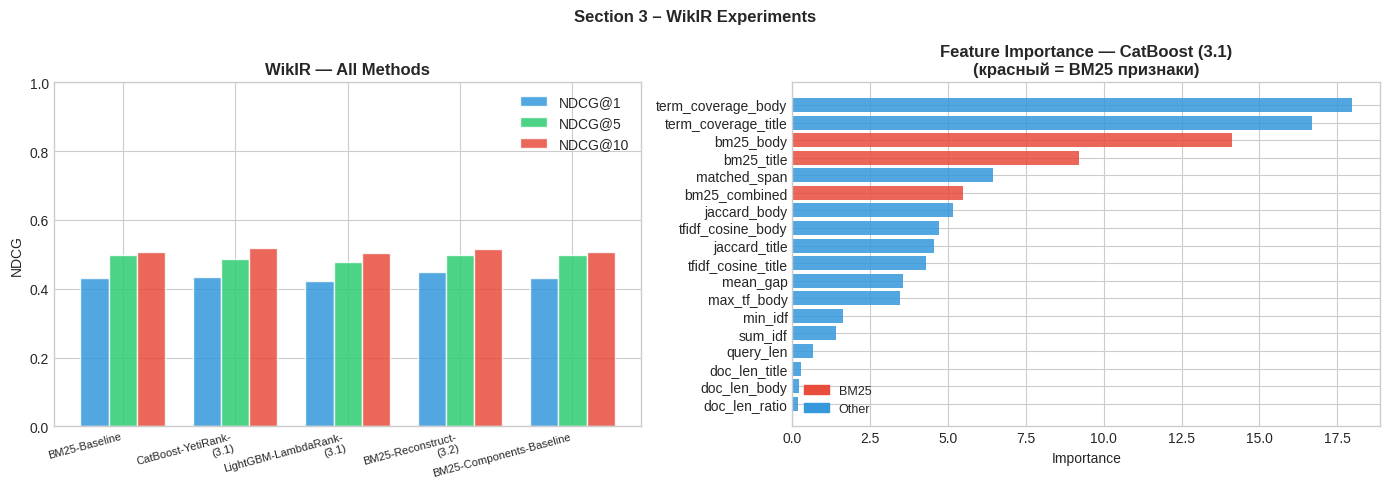

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
methods = list(results_wikir.keys())
for i, (k, col) in enumerate(zip([1,5,10], ['#3498db','#2ecc71','#e74c3c'])):
    vals = [results_wikir[m][f'NDCG@{k}'] for m in methods]
    ax.bar(np.arange(len(methods)) + i*0.25, vals, 0.25,
           label=f'NDCG@{k}', color=col, alpha=0.85, edgecolor='white')
ax.set_xticks(np.arange(len(methods)) + 0.25)
ax.set_xticklabels([m.replace(' (','-\n(') for m in methods], fontsize=8, rotation=15, ha='right')
ax.set_ylabel('NDCG'); ax.set_ylim(0, 1)
ax.set_title('WikIR — All Methods', fontweight='bold'); ax.legend()

ax = axes[1]
fi_wk = model_wk.get_feature_importance(data=pool_wk_tr, type='PredictionValuesChange')
fi_df  = pd.DataFrame({'feature': WIKIR_FEATURES, 'importance': fi_wk}).sort_values('importance', ascending=False)
is_bm25 = fi_df['feature'].isin(['bm25_body','bm25_title','bm25_combined'])
ax.barh(fi_df['feature'], fi_df['importance'],
        color=['#e74c3c' if b else '#3498db' for b in is_bm25], alpha=0.85)
ax.invert_yaxis(); ax.set_xlabel('Importance')
ax.set_title('Feature Importance — CatBoost (3.1)\n(красный = BM25 признаки)', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color='#e74c3c', label='BM25'),
                   mpatches.Patch(color='#3498db', label='Other')], fontsize=9)
plt.suptitle('Section 3 – WikIR Experiments', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


**Выводы по части 3 (WikIR):**

Эксперименты на WikIR показали, что улучшить сильный BM25-baseline сложно, но возможно.  
В задаче 3.1 лучший результат дал CatBoost-YetiRank: он немного улучшил качество ранжирования относительно исходного BM25 по NDCG@10 (0.5190 vs 0.5062, прирост около +2.5%). Это означает, что дополнительные признаки — покрытие терминов, proximity, TF-IDF cosine, Jaccard, длины документа и запроса — действительно несут полезный сигнал, но этот сигнал ограничен, потому что в WikIR запросы часто почти совпадают с заголовками релевантных статей, а значит сам BM25 уже очень силён.

LightGBM-LambdaRank в задаче 3.1 не смог стабильно превзойти baseline. Это указывает на то, что при небольшом числе тестовых запросов и относительно простом сигнале признаков качество оценки сильно зависит от отдельных перестановок в top-k, а выигрыш модели становится нестабильным.

Задача 3.2 показала, что BM25 можно достаточно точно реконструировать из его компонент. Модель, обученная только на признаках TF, IDF и длины документа, получила качество, сопоставимое с исходным BM25, и даже немного улучшила NDCG@1. Это говорит о том, что основная сила BM25 действительно сосредоточена в этих базовых сигналах, а обучаемый ранкер способен переоценить их чуть более удачно для постановки самого релевантного документа на первое место.
